In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote
from matplotlib import pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# параметры подключения
username = "student"
password = "123456sql@"
host = "rc1b-cpsjckr2wfkuk61s.mdb.yandexcloud.net"
port = "6432"
database = "Northwind"

# Кодируем пароль
encoded_password = quote(password)
print(encoded_password)

# Формируем строку подключения
connection_string = f'postgresql+psycopg2://{username}:{encoded_password}@{host}:{port}/{database}'
engine = create_engine(connection_string)

123456sql%40


In [3]:
#sql запрос
query = """
select date(date_paid) as date_paid,
sum(quantity * price) as gmv_paid,
sum(quantity * price * commission) as margin
from sandbox.orders o join sandbox.order_details od on o.order_id = od.order_id
group by date(date_paid)
"""
df = pd.read_sql_query(query, engine)
df.head()

,date_paid,gmv_paid,margin
0,None,118862.72,30794.0094
1,2017-06-13,20607.31,5411.1759
2,2017-08-24,18891.38,4561.2177
3,2017-09-06,33878.48,8497.0062
4,2017-01-10,555.37,173.1344


In [4]:
df['date_paid'] = df.date_paid.astype('datetime64[ns]')
df['month_paid'] = df.date_paid.astype('datetime64[ns]').dt.to_period('M').dt.to_timestamp()
df['week_paid'] = df.date_paid.astype('datetime64[ns]').dt.to_period('W').dt.to_timestamp()

In [5]:
df_monthly = df.groupby('month_paid', as_index = False).agg({'gmv_paid':'sum', 'margin':'sum'})

In [6]:
df_monthly.head()

,month_paid,gmv_paid,margin
0,2017-01-01,82381.46,21244.7335
1,2017-02-01,215954.90,54319.5607
2,2017-03-01,369711.61,93925.7885
3,2017-04-01,297326.46,75739.1784
4,2017-05-01,501495.56,130611.6871


In [7]:
df_monthly['margin_perсent'] = round(df_monthly['margin']/df_monthly['gmv_paid']*100,1)

In [8]:
df_monthly.tail()

,month_paid,gmv_paid,margin,margin_perсent
14,2018-03-01,955820.02,243570.6316,25.5
15,2018-04-01,1001468.98,256819.1359,25.6
16,2018-05-01,993582.31,261785.6913,26.3
17,2018-06-01,869576.34,224859.4014,25.9
18,2018-07-01,286455.15,74758.6222,26.1


#### Смотрим GMV по дате выкупа

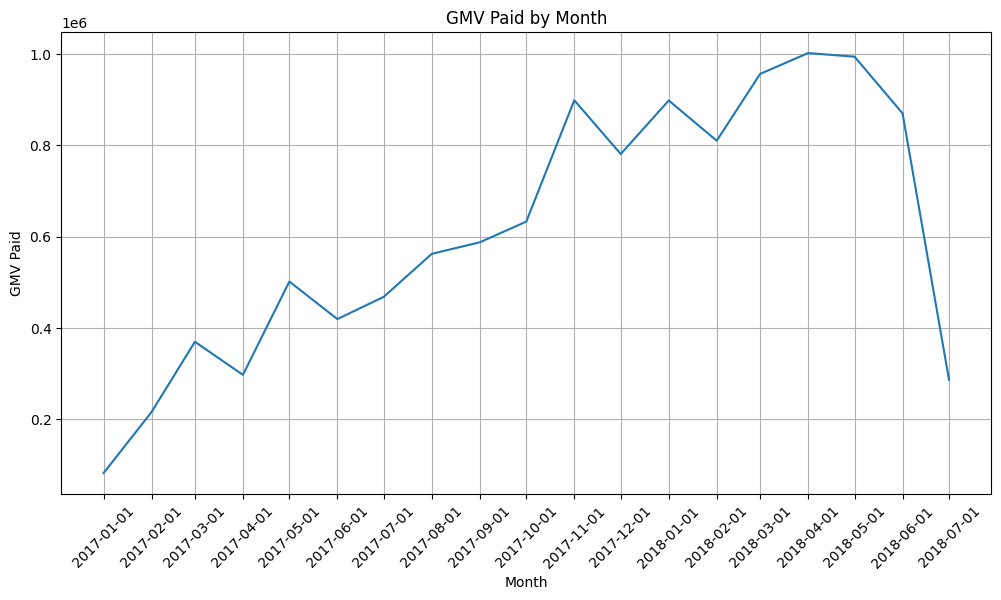

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(
        df_monthly.month_paid,
        df_monthly.gmv_paid
        )
plt.xticks(
            df_monthly.month_paid.unique(), 
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('GMV Paid')
plt.title('GMV Paid by Month')
plt.xlabel('Month')
plt.grid()
plt.show()

#### Смотрим динамику маржи и маржи в процентах

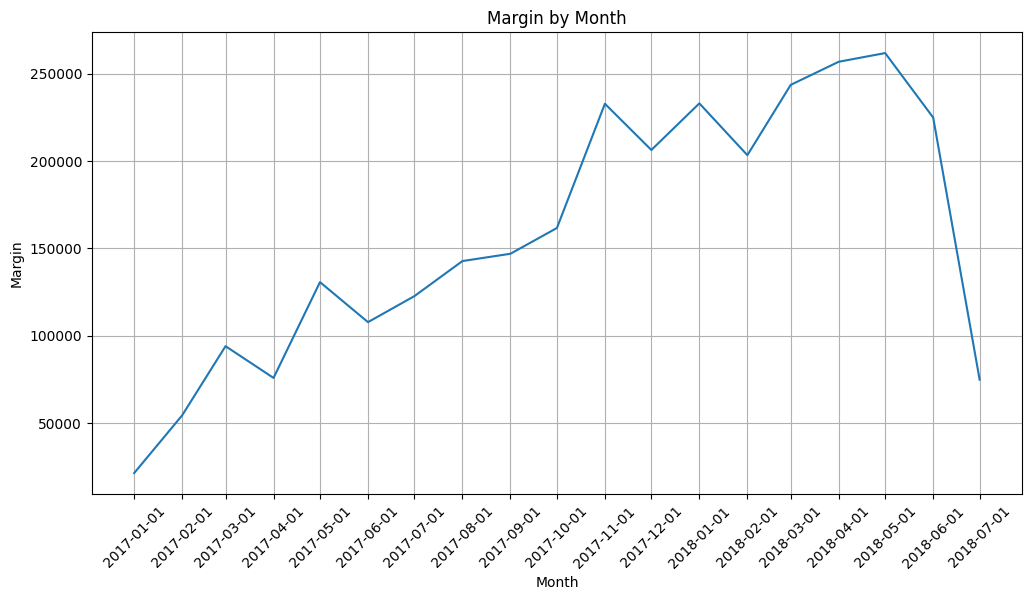

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(
        df_monthly.month_paid,
        df_monthly.margin
        )
plt.xticks(
            df_monthly.month_paid.unique(), 
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('Margin')
plt.title('Margin by Month')
plt.xlabel('Month')
plt.grid()
plt.show()

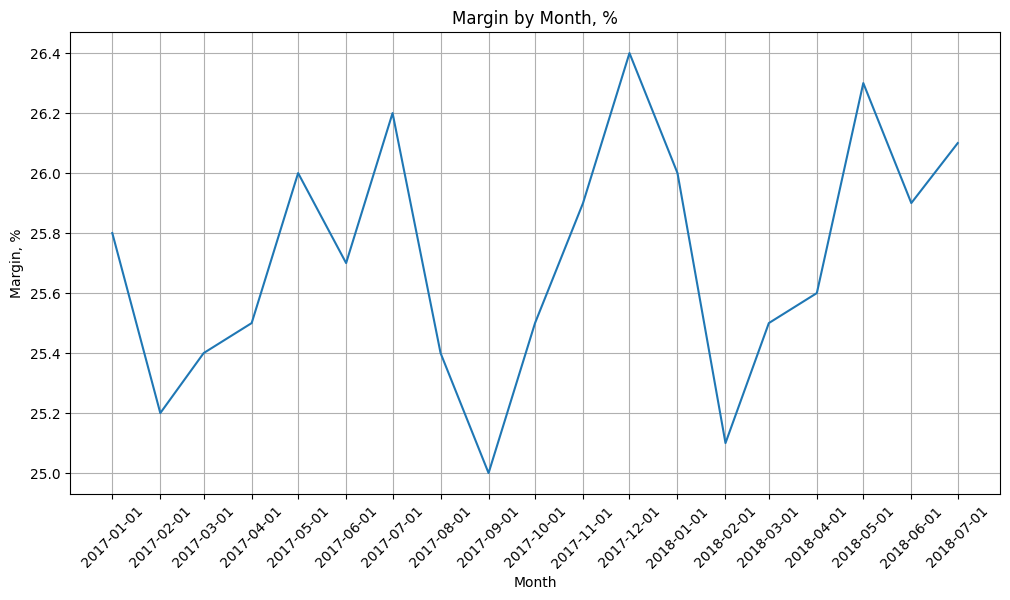

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(
        df_monthly.month_paid,
        df_monthly.margin_perсent
        )
plt.xticks(
            df_monthly.month_paid.unique(), 
           rotation=45)  #Поворот меток на 45% для лучшей читаемости
plt.ylabel('Margin, %')
plt.title('Margin by Month, %')
plt.xlabel('Month')
plt.grid()
plt.show()

In [12]:
df_monthly.tail(3)

,month_paid,gmv_paid,margin,margin_perсent
16,2018-05-01,993582.31,261785.6913,26.3
17,2018-06-01,869576.34,224859.4014,25.9
18,2018-07-01,286455.15,74758.6222,26.1


#### Считаем приросты

In [13]:
#прирост Margin
round((df_monthly.tail(3).T[17][2]/df_monthly.tail(3).T[16][2]-1)*100,1)

/var/folders/40/syqp3b6j0cdf65gmn816vtx40000gn/T/ipykernel_33697/945182101.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round((df_monthly.tail(3).T[17][2]/df_monthly.tail(3).T[16][2]-1)*100,1)
/var/folders/40/syqp3b6j0cdf65gmn816vtx40000gn/T/ipykernel_33697/945182101.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  round((df_monthly.tail(3).T[17][2]/df_monthly.tail(3).T[16][2]-1)*100,1)


-14.1

In [14]:
#прирост Margin, %
df_monthly.tail(3).T[17][3]-df_monthly.tail(3).T[16][3]

/var/folders/40/syqp3b6j0cdf65gmn816vtx40000gn/T/ipykernel_33697/3846945352.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_monthly.tail(3).T[17][3]-df_monthly.tail(3).T[16][3]
/var/folders/40/syqp3b6j0cdf65gmn816vtx40000gn/T/ipykernel_33697/3846945352.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_monthly.tail(3).T[17][3]-df_monthly.tail(3).T[16][3]


-0.40000000000000213